🚀 Setting up COCO dataset in Colab...
📊 Creating datasets...
loading annotations into memory...
Done (t=2.34s)
creating index...
index created!
✅ Loaded 5000 images from COCO dataset
loading annotations into memory...
Done (t=2.02s)
creating index...
index created!
✅ Loaded 5000 images from COCO dataset
📈 Training samples: 800
📊 Validation samples: 200
🔧 Using device: cuda
🎯 Starting training...


Epoch 1/5 [Val]: 100%|██████████| 25/25 [00:06<00:00,  3.95it/s, Loss=0.3083, IoU=0.6917]



📊 Epoch 1 Summary:
   Train Loss: 0.4576 | Val Loss: 0.3111
   Train IoU:  0.6251 | Val IoU:  0.6903
   Train Acc:  0.7891 | Val Acc:  0.8609
------------------------------------------------------------


Epoch 2/5 [Val]: 100%|██████████| 25/25 [00:06<00:00,  3.86it/s, Loss=0.2593, IoU=0.7356]



📊 Epoch 2 Summary:
   Train Loss: 0.3793 | Val Loss: 0.2986
   Train IoU:  0.6722 | Val IoU:  0.7395
   Train Acc:  0.8276 | Val Acc:  0.8754
------------------------------------------------------------


...


📊 Epoch 3 Summary:
   Train Loss: 0.3656 | Val Loss: 0.2760
   Train IoU:  0.6791 | Val IoU:  0.7492
   Train Acc:  0.8349 | Val Acc:  0.8825
------------------------------------------------------------


Epoch 4/5 [Val]: 100%|██████████| 25/25 [00:06<00:00,  4.03it/s, Loss=0.1698, IoU=0.8666]



📊 Epoch 4 Summary:
   Train Loss: 0.3418 | Val Loss: 0.2284
   Train IoU:  0.7007 | Val IoU:  0.7877
   Train Acc:  0.8481 | Val Acc:  0.9060
------------------------------------------------------------


Epoch 5/5 [Val]: 100%|██████████| 25/25 [00:06<00:00,  3.85it/s, Loss=0.1827, IoU=0.8125]



📊 Epoch 5 Summary:
   Train Loss: 0.3415 | Val Loss: 0.2270
   Train IoU:  0.7044 | Val IoU:  0.7930
   Train Acc:  0.8497 | Val Acc:  0.9082
------------------------------------------------------------
💾 Model saved as deeplabv3_segmentation.pth


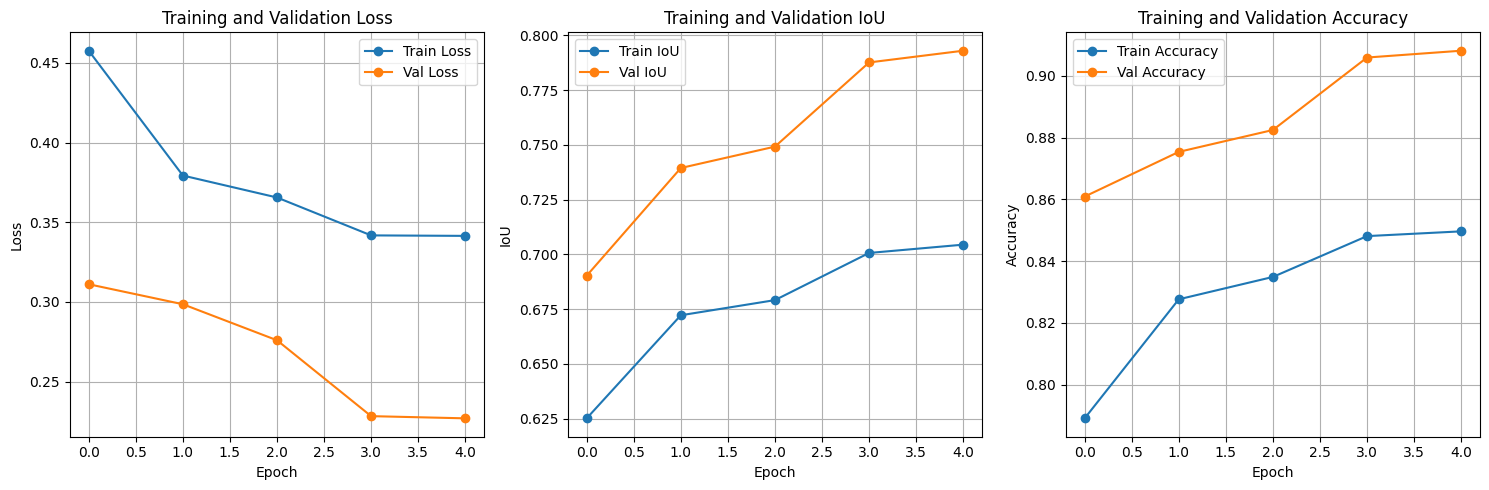

✅ TRAINING COMPLETED! Model saved and ready for next step.


In [3]:
# =============================================
# TRAINING AND SAVING THE MODEL - COLAB
# =============================================

import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn
import torch.optim as optim
from torchvision.models.segmentation import deeplabv3_resnet50
from tqdm import tqdm

print("🚀 Setting up COCO dataset in Colab...")

# Colab paths for COCO dataset
images_path = "/content/val2017"
annotations_path = "/content/annotations/instances_val2017.json"

# Verify COCO dataset exists
if not os.path.exists(images_path):
    print("📥 Downloading COCO dataset...")
    !wget -q http://images.cocodataset.org/zips/val2017.zip
    !wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
    !unzip -q val2017.zip
    !unzip -q annotations_trainval2017.zip
    print("✅ COCO dataset downloaded!")

class CocoMaskedDataset(Dataset):
    def __init__(self, images_path, annotations_path, transform=None):
        self.images_path = images_path
        self.coco = COCO(annotations_path)
        self.img_ids = self.coco.getImgIds()
        self.transform = transform
        print(f"✅ Loaded {len(self.img_ids)} images from COCO dataset")

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.images_path, img_info['file_name'])

        img = np.array(Image.open(img_path).convert("RGB"))

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        for ann in anns:
            m = self.coco.annToMask(ann)
            mask = np.maximum(mask, m)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]

        return img, mask.long()

# Enhanced transformations
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Create datasets
print("📊 Creating datasets...")
train_dataset = CocoMaskedDataset(images_path, annotations_path, transform=train_transform)
val_dataset = CocoMaskedDataset(images_path, annotations_path, transform=val_transform)

# Use smaller subset for faster training (remove this for full training)
train_indices = list(range(min(800, len(train_dataset))))
val_indices = list(range(min(200, len(val_dataset))))

train_dataset = torch.utils.data.Subset(train_dataset, train_indices)
val_dataset = torch.utils.data.Subset(val_dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

print(f"📈 Training samples: {len(train_dataset)}")
print(f"📊 Validation samples: {len(val_dataset)}")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔧 Using device: {device}")

# Model setup
model = deeplabv3_resnet50(pretrained=True)
model.classifier[4] = nn.Conv2d(256, 2, kernel_size=1)
model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Metrics functions
def calculate_iou(pred, target):
    pred_labels = torch.argmax(pred, dim=1)
    ious = []
    for class_id in [0, 1]:
        pred_mask = (pred_labels == class_id)
        target_mask = (target == class_id)
        intersection = (pred_mask & target_mask).sum().item()
        union = (pred_mask | target_mask).sum().item()
        if union == 0:
            ious.append(1.0)
        else:
            ious.append(intersection / union)
    return sum(ious) / len(ious)

def calculate_pixel_accuracy(pred, target):
    pred_labels = torch.argmax(pred, dim=1)
    correct_pixels = (pred_labels == target).sum().item()
    total_pixels = target.numel()
    return correct_pixels / total_pixels

# Enhanced training function with metrics
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    train_losses, val_losses = [], []
    train_ious, val_ious = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        # Training
        model.train()
        epoch_train_loss, epoch_train_iou, epoch_train_acc = 0, 0, 0

        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for images, masks in train_pbar:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)["out"]
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()
            epoch_train_iou += calculate_iou(outputs, masks)
            epoch_train_acc += calculate_pixel_accuracy(outputs, masks)

            train_pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'IoU': f'{calculate_iou(outputs, masks):.4f}'
            })

        # Validation
        model.eval()
        epoch_val_loss, epoch_val_iou, epoch_val_acc = 0, 0, 0

        val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        with torch.no_grad():
            for images, masks in val_pbar:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)["out"]
                loss = criterion(outputs, masks)

                epoch_val_loss += loss.item()
                epoch_val_iou += calculate_iou(outputs, masks)
                epoch_val_acc += calculate_pixel_accuracy(outputs, masks)

                val_pbar.set_postfix({
                    'Loss': f'{loss.item():.4f}',
                    'IoU': f'{calculate_iou(outputs, masks):.4f}'
                })

        # Calculate averages
        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_train_iou = epoch_train_iou / len(train_loader)
        avg_train_acc = epoch_train_acc / len(train_loader)

        avg_val_loss = epoch_val_loss / len(val_loader)
        avg_val_iou = epoch_val_iou / len(val_loader)
        avg_val_acc = epoch_val_acc / len(val_loader)

        # Store metrics
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_ious.append(avg_train_iou)
        val_ious.append(avg_val_iou)
        train_accs.append(avg_train_acc)
        val_accs.append(avg_val_acc)

        print(f"\n📊 Epoch {epoch+1} Summary:")
        print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"   Train IoU:  {avg_train_iou:.4f} | Val IoU:  {avg_val_iou:.4f}")
        print(f"   Train Acc:  {avg_train_acc:.4f} | Val Acc:  {avg_val_acc:.4f}")
        print("-" * 60)

    return model, {
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_ious': train_ious, 'val_ious': val_ious,
        'train_accs': train_accs, 'val_accs': val_accs
    }

# Train the model
print("🎯 Starting training...")
trained_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

# Save the model
model_save_path = "deeplabv3_segmentation.pth"
torch.save(trained_model.state_dict(), model_save_path)
print(f"💾 Model saved as {model_save_path}")

# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(metrics['train_losses'], label='Train Loss', marker='o')
plt.plot(metrics['val_losses'], label='Val Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(metrics['train_ious'], label='Train IoU', marker='o')
plt.plot(metrics['val_ious'], label='Val IoU', marker='o')
plt.title('Training and Validation IoU')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(metrics['train_accs'], label='Train Accuracy', marker='o')
plt.plot(metrics['val_accs'], label='Val Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ TRAINING COMPLETED! Model saved and ready for next step.")